In [106]:
# 🛠️ Advanced imports for production ML

# Suppress warnings for cleaner outputs
import warnings
warnings.filterwarnings('ignore')

# 🔧 Core Python libraries
import numpy as np           # Efficient numerical computations
import pandas as pd          # Data manipulation and analysis
import matplotlib.pyplot as plt  # Basic plotting
import seaborn as sns        # Advanced visualization
from scipy import stats      # Statistical functions
import joblib               # Save/load large models and preprocessing objects
import json                 # Handle JSON configs and outputs
from datetime import datetime  # Timestamping for logs
import os                   # File system operations
import time                 # Time tracking for experiments


import xgboost as xgb
from xgboost import plot_tree

# 🧰 Sklearn libraries - expanded for advanced ML workflows
from sklearn.datasets import fetch_california_housing  # Real-world dataset
from sklearn.model_selection import (
    train_test_split,     # Split data into train/test sets
    cross_val_score,      # Cross-validation scoring
    GridSearchCV,         # Hyperparameter tuning (grid search)
    RandomizedSearchCV    # Hyperparameter tuning (randomized search)
)
from sklearn.preprocessing import (
    StandardScaler,       # Feature scaling (zero-mean, unit variance)
    RobustScaler,         # Scaling robust to outliers
    PolynomialFeatures    # Generate polynomial features for non-linear relationships
)
from sklearn.pipeline import Pipeline, FeatureUnion  # Build modular pipelines
from sklearn.compose import ColumnTransformer         # Apply different preprocessing to columns
from sklearn.feature_selection import (
    SelectKBest,          # Univariate feature selection
    f_regression,         # Scoring function for regression
    RFE                   # Recursive feature elimination
)
from sklearn.linear_model import (
    LinearRegression,     # Baseline regression
    Ridge,                # L2-regularized regression
    Lasso,                # L1-regularized regression
    ElasticNet            # Combination of L1 and L2 regularization
)
from sklearn.ensemble import (
    RandomForestRegressor,       # Ensemble of decision trees
    GradientBoostingRegressor,   # Boosted trees for regression
    VotingRegressor              # Combine multiple regressors
)
from sklearn.svm import SVR               # Support Vector Regression
from sklearn.metrics import (
    mean_squared_error,  # Regression metric
    r2_score,            # Regression metric
    mean_absolute_error  # Regression metric
)
from sklearn.inspection import (
    permutation_importance,       # Feature importance
    PartialDependenceDisplay      # Partial dependence plots
)

# 🧪 Advanced model tracking with MLflow
import mlflow                  # Experiment tracking
import mlflow.sklearn          # Log sklearn models
from mlflow.models.signature import infer_signature  # Auto-capture input/output schema for reproducible deployment


In [3]:
DATA_FOLDER='Data'
df_store=pd.read_csv('store.csv')
df_test=pd.read_csv('test.csv')
df_train=pd.read_csv('train.csv')


In [4]:
df_store.head()


,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [5]:
df_train.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
0,1,5,2015-07-31,5263,555,1,1,0,1
1,2,5,2015-07-31,6064,625,1,1,0,1
2,3,5,2015-07-31,8314,821,1,1,0,1
3,4,5,2015-07-31,13995,1498,1,1,0,1
4,5,5,2015-07-31,4822,559,1,1,0,1


In [6]:
df = pd.merge(df_train, df_store, on='Store', how='left')


In [7]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [8]:
# drop columns with too many null values 
df.drop(["CompetitionOpenSinceMonth","CompetitionOpenSinceYear","Promo2SinceWeek",
             "Promo2SinceYear","PromoInterval"],axis=1, inplace=True,)

In [9]:
df.isnull().sum()

Store                     0
DayOfWeek                 0
Date                      0
Sales                     0
Customers                 0
Open                      0
Promo                     0
StateHoliday              0
SchoolHoliday             0
StoreType                 0
Assortment                0
CompetitionDistance    2642
Promo2                    0
dtype: int64

In [11]:
# Fix null values 
df["CompetitionDistance"].fillna(df["CompetitionDistance"].median(),inplace=True)
df.isnull().sum()

Store                  0
DayOfWeek              0
Date                   0
Sales                  0
Customers              0
Open                   0
Promo                  0
StateHoliday           0
SchoolHoliday          0
StoreType              0
Assortment             0
CompetitionDistance    0
Promo2                 0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 13 columns):
 #   Column               Non-Null Count    Dtype  
---  ------               --------------    -----  
 0   Store                1017209 non-null  int64  
 1   DayOfWeek            1017209 non-null  int64  
 2   Date                 1017209 non-null  object 
 3   Sales                1017209 non-null  int64  
 4   Customers            1017209 non-null  int64  
 5   Open                 1017209 non-null  int64  
 6   Promo                1017209 non-null  int64  
 7   StateHoliday         1017209 non-null  object 
 8   SchoolHoliday        1017209 non-null  int64  
 9   StoreType            1017209 non-null  object 
 10  Assortment           1017209 non-null  object 
 11  CompetitionDistance  1017209 non-null  float64
 12  Promo2               1017209 non-null  int64  
dtypes: float64(1), int64(8), object(4)
memory usage: 100.9+ MB


In [13]:

df['Date'] = pd.to_datetime(df['Date'])
df['Day'] = df['Date'].dt.day
df['Month'] = df['Date'].dt.month
df['Year'] = df['Date'].dt.year
df.drop(columns=['Date'], inplace=True)
df.sample(5)

,Store,DayOfWeek,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Day,Month,Year
859459,580,3,7793,1336,1,0,0,0,a,c,170.0,0,22,5,2013
971554,60,7,0,0,0,0,0,0,d,c,5540.0,0,10,2,2013
926542,763,6,5957,609,1,0,0,0,d,c,32240.0,0,23,3,2013
892809,480,1,7134,839,1,1,0,0,a,a,300.0,0,22,4,2013
77564,630,6,2682,303,1,0,0,0,a,a,1690.0,0,23,5,2015


In [ ]:
df = df.drop(df[df["Sales"] == 0].index)


(844338, 15)

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 15 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Store                844338 non-null  int64  
 1   DayOfWeek            844338 non-null  int64  
 2   Sales                844338 non-null  int64  
 3   Customers            844338 non-null  int64  
 4   Open                 844338 non-null  int64  
 5   Promo                844338 non-null  int64  
 6   StateHoliday         844338 non-null  object 
 7   SchoolHoliday        844338 non-null  int64  
 8   StoreType            844338 non-null  object 
 9   Assortment           844338 non-null  object 
 10  CompetitionDistance  844338 non-null  float64
 11  Promo2               844338 non-null  int64  
 12  Day                  844338 non-null  int32  
 13  Month                844338 non-null  int32  
 14  Year                 844338 non-null  int32  
dtypes: float64(1), int32(

In [16]:
# drop customers column as its unpredicted in future days
df.drop(["Customers"],axis=1, inplace=True,)
df.head()

,Store,DayOfWeek,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Day,Month,Year
0,1,5,5263,1,1,0,1,c,a,1270.0,0,31,7,2015
1,2,5,6064,1,1,0,1,a,a,570.0,1,31,7,2015
2,3,5,8314,1,1,0,1,a,a,14130.0,1,31,7,2015
3,4,5,13995,1,1,0,1,c,c,620.0,0,31,7,2015
4,5,5,4822,1,1,0,1,a,a,29910.0,0,31,7,2015


In [17]:
# drop open Column as its obious if closed no sales and already removed 0 sales record from df
df.drop(["Open"],axis=1, inplace=True,)
df.head()

,Store,DayOfWeek,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Day,Month,Year
0,1,5,5263,1,0,1,c,a,1270.0,0,31,7,2015
1,2,5,6064,1,0,1,a,a,570.0,1,31,7,2015
2,3,5,8314,1,0,1,a,a,14130.0,1,31,7,2015
3,4,5,13995,1,0,1,c,c,620.0,0,31,7,2015
4,5,5,4822,1,0,1,a,a,29910.0,0,31,7,2015


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844338 entries, 0 to 1017190
Data columns (total 13 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Store                844338 non-null  int64  
 1   DayOfWeek            844338 non-null  int64  
 2   Sales                844338 non-null  int64  
 3   Promo                844338 non-null  int64  
 4   StateHoliday         844338 non-null  object 
 5   SchoolHoliday        844338 non-null  int64  
 6   StoreType            844338 non-null  object 
 7   Assortment           844338 non-null  object 
 8   CompetitionDistance  844338 non-null  float64
 9   Promo2               844338 non-null  int64  
 10  Day                  844338 non-null  int32  
 11  Month                844338 non-null  int32  
 12  Year                 844338 non-null  int32  
dtypes: float64(1), int32(3), int64(6), object(3)
memory usage: 80.5+ MB


In [19]:
# Value	Meaning	Expected Impact on Sales
# 0	No Holiday	Normal business operations.
# a	Public Holiday	General holidays (e.g., Reunification Day). Shops usually closed.
# b	Easter Holiday	Easter. Significant impact on sales leading up to it.
# c	Christmas	Christmas. High sales volume before, likely closed during.
df["StateHoliday"].unique()

array(['0', 'a', 'b', 'c', 0], dtype=object)

In [20]:
df["StateHoliday"] = df["StateHoliday"].replace(0, '0')
df["StateHoliday"].unique()

array(['0', 'a', 'b', 'c'], dtype=object)

In [21]:
# Lambda function: if DayOfWeek is 6 or 7, return 1, else 0
df['Is_Weekend'] = df['DayOfWeek'].apply(lambda x: 1 if x >= 6 else 0)

In [22]:
# Map motnth to season to check wether which season the sales boost 
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Season'] = df['Month'].apply(get_season)
df.head()

,Store,DayOfWeek,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Day,Month,Year,Is_Weekend,Season
0,1,5,5263,1,0,1,c,a,1270.0,0,31,7,2015,0,Summer
1,2,5,6064,1,0,1,a,a,570.0,1,31,7,2015,0,Summer
2,3,5,8314,1,0,1,a,a,14130.0,1,31,7,2015,0,Summer
3,4,5,13995,1,0,1,c,c,620.0,0,31,7,2015,0,Summer
4,5,5,4822,1,0,1,a,a,29910.0,0,31,7,2015,0,Summer


In [23]:
# 1. Sort the data! (CRITICAL STEP)
# Ensure data is ordered by Store and Date (Ascending)
# Note: Ensure you have a 'Year' column if your data spans multiple years.
df = df.sort_values(by=['Store', 'Month', 'Day'])

# 2. Create Lag 1 (Yesterday's Sales)
# We group by 'Store' so we don't mix data between different stores.
df['Sales_Lag_1'] = df.groupby('Store')['Sales'].shift(1)

# 3. Create Lag 7 (Last Week's Sales)
df['Sales_Lag_7'] = df.groupby('Store')['Sales'].shift(7)

# 4. (Optional) Fill NaN values
# The first row of every store will be NaN (because there is no "yesterday").
# You can drop them or fill them with 0.
df = df.dropna()

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 836533 entries, 1012750 to 611349
Data columns (total 17 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Store                836533 non-null  int64  
 1   DayOfWeek            836533 non-null  int64  
 2   Sales                836533 non-null  int64  
 3   Promo                836533 non-null  int64  
 4   StateHoliday         836533 non-null  object 
 5   SchoolHoliday        836533 non-null  int64  
 6   StoreType            836533 non-null  object 
 7   Assortment           836533 non-null  object 
 8   CompetitionDistance  836533 non-null  float64
 9   Promo2               836533 non-null  int64  
 10  Day                  836533 non-null  int32  
 11  Month                836533 non-null  int32  
 12  Year                 836533 non-null  int32  
 13  Is_Weekend           836533 non-null  int64  
 14  Season               836533 non-null  object 
 15  Sales_Lag_1     

In [27]:
# CompetitionDistance can be noisy. Group them
df['CompetitionDistance'] = pd.cut(df['CompetitionDistance'],
                               bins=[0, 500, 2000, np.inf],
                               labels=['Near', 'Medium', 'Far'],
                               right=False,
                               include_lowest=True)
df.head()

,Store,DayOfWeek,Sales,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Day,Month,Year,Is_Weekend,Season,Sales_Lag_1,Sales_Lag_7
1012750,1,5,4486,0,0,1,c,a,Medium,0,4,1,2013,0,Winter,5173.0,5509.0
230805,1,1,6239,1,0,1,c,a,Medium,0,5,1,2015,0,Winter,4486.0,4969.0
1011635,1,6,4997,0,0,1,c,a,Medium,0,5,1,2013,1,Winter,6239.0,5530.0
229690,1,2,4574,1,0,1,c,a,Medium,0,6,1,2015,0,Winter,4997.0,5023.0
603545,1,1,6194,1,0,1,c,a,Medium,0,6,1,2014,0,Winter,4574.0,4190.0


In [28]:
#Rearrange columns with logical grouping of features and Sales as last column
cols = [
    # Store characteristics 
    'Store', 'StoreType', 'Assortment',
    
    # Time features
    'DayOfWeek', 'Day', 'Month', 'Is_Weekend', 'Season',
    
    # Competition features
    'CompetitionDistance',
    
    # Promotion features 
    'Promo', 'Promo2',
    
    # Status indicators
    'StateHoliday', 'SchoolHoliday',
    
    # Target variable
    'Sales_Lag_1','Sales_Lag_7','Sales'
]

df = df[cols]
df.head()

,Store,StoreType,Assortment,DayOfWeek,Day,Month,Is_Weekend,Season,CompetitionDistance,Promo,Promo2,StateHoliday,SchoolHoliday,Sales_Lag_1,Sales_Lag_7,Sales
1012750,1,c,a,5,4,1,0,Winter,Medium,0,0,0,1,5173.0,5509.0,4486
230805,1,c,a,1,5,1,0,Winter,Medium,1,0,0,1,4486.0,4969.0,6239
1011635,1,c,a,6,5,1,1,Winter,Medium,0,0,0,1,6239.0,5530.0,4997
229690,1,c,a,2,6,1,0,Winter,Medium,1,0,0,1,4997.0,5023.0,4574
603545,1,c,a,1,6,1,0,Winter,Medium,1,0,0,1,4574.0,4190.0,6194


In [34]:
# One-Hot Encoding 
# For nominal variables with few categories. 
# drop_first=True avoids multicollinearity (dummy variable trap).
nominal_cols = ['StoreType', 'Assortment', 'StateHoliday', 'Season']
df = pd.get_dummies(df, columns=nominal_cols, drop_first=True)

In [35]:
# Target Encoding 
# For high cardinality 'Store' column.
# WARNING: In a real ML pipeline, compute this mean on X_train ONLY and map to X_test 
# to avoid data leakage.
store_means = df.groupby('Store')['Sales'].mean()
df['Store_encoded'] = df['Store']
df.drop(['Store'], axis=1, inplace=True)

In [ ]:
# Odinal Encoding
# 1. Define the mapping
comp_dist_map = {'Near': 0, 'Medium': 1, 'Far': 2}

# 2. Create the new encoded column by mapping the values
df['CompetitionDistance_encoded'] = df['CompetitionDistance'].map(comp_dist_map)

# 3. Drop the original column
df.drop(['CompetitionDistance'], axis=1, inplace=True)

In [ ]:
df["CompetitionDistance_encoded"].unique()

[1, 2, 0]
Categories (3, int64): [0 < 1 < 2]

In [57]:
df.head()


,DayOfWeek,Day,Month,Is_Weekend,Promo,Promo2,SchoolHoliday,Sales_Lag_1,Sales_Lag_7,Sales,...,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,StateHoliday_c,Season_Spring,Season_Summer,Season_Winter,Store_encoded,CompetitionDistance_encoded
1012750,5,4,1,0,0,0,1,5173.0,5509.0,4486,...,False,False,False,False,False,False,False,True,1,1
230805,1,5,1,0,1,0,1,4486.0,4969.0,6239,...,False,False,False,False,False,False,False,True,1,1
1011635,6,5,1,1,0,0,1,6239.0,5530.0,4997,...,False,False,False,False,False,False,False,True,1,1
229690,2,6,1,0,1,0,1,4997.0,5023.0,4574,...,False,False,False,False,False,False,False,True,1,1
603545,1,6,1,0,1,0,1,4574.0,4190.0,6194,...,False,False,False,False,False,False,False,True,1,1


In [58]:
bool_col=df.select_dtypes(include=['bool']).columns

In [61]:
df[bool_col]=df[bool_col].astype(int)

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 836533 entries, 1012750 to 611349
Data columns (total 23 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   DayOfWeek                    836533 non-null  int64   
 1   Day                          836533 non-null  int32   
 2   Month                        836533 non-null  int32   
 3   Is_Weekend                   836533 non-null  int64   
 4   Promo                        836533 non-null  int64   
 5   Promo2                       836533 non-null  int64   
 6   SchoolHoliday                836533 non-null  int64   
 7   Sales_Lag_1                  836533 non-null  float64 
 8   Sales_Lag_7                  836533 non-null  float64 
 9   Sales                        836533 non-null  int64   
 10  StoreType_b                  836533 non-null  int64   
 11  StoreType_c                  836533 non-null  int64   
 12  StoreType_d                  836533 non-nul

In [63]:
df.head()

,DayOfWeek,Day,Month,Is_Weekend,Promo,Promo2,SchoolHoliday,Sales_Lag_1,Sales_Lag_7,Sales,...,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,StateHoliday_c,Season_Spring,Season_Summer,Season_Winter,Store_encoded,CompetitionDistance_encoded
1012750,5,4,1,0,0,0,1,5173.0,5509.0,4486,...,0,0,0,0,0,0,0,1,1,1
230805,1,5,1,0,1,0,1,4486.0,4969.0,6239,...,0,0,0,0,0,0,0,1,1,1
1011635,6,5,1,1,0,0,1,6239.0,5530.0,4997,...,0,0,0,0,0,0,0,1,1,1
229690,2,6,1,0,1,0,1,4997.0,5023.0,4574,...,0,0,0,0,0,0,0,1,1,1
603545,1,6,1,0,1,0,1,4574.0,4190.0,6194,...,0,0,0,0,0,0,0,1,1,1


In [64]:
from sklearn.model_selection import (
    train_test_split,     # Split data into train/test sets
    cross_val_score,      # Cross-validation scoring
    GridSearchCV,         # Hyperparameter tuning (grid search)
    RandomizedSearchCV    # Hyperparameter tuning (randomized search)
)
X = df.drop('Sales', axis=1)
y = df['Sales']

# Split into train and test sets


In [ ]:
X.info()


<class 'pandas.core.frame.DataFrame'>
Index: 836533 entries, 1012750 to 611349
Data columns (total 22 columns):
 #   Column                       Non-Null Count   Dtype   
---  ------                       --------------   -----   
 0   DayOfWeek                    836533 non-null  int64   
 1   Day                          836533 non-null  int32   
 2   Month                        836533 non-null  int32   
 3   Is_Weekend                   836533 non-null  int64   
 4   Promo                        836533 non-null  int64   
 5   Promo2                       836533 non-null  int64   
 6   SchoolHoliday                836533 non-null  int64   
 7   Sales_Lag_1                  836533 non-null  float64 
 8   Sales_Lag_7                  836533 non-null  float64 
 9   StoreType_b                  836533 non-null  int64   
 10  StoreType_c                  836533 non-null  int64   
 11  StoreType_d                  836533 non-null  int64   
 12  Assortment_b                 836533 non-nul

In [40]:
# 🧪 Advanced model tracking with MLflow
import mlflow                  # Experiment tracking
import mlflow.sklearn          # Log sklearn models
from mlflow.models.signature import infer_signature  # Auto-capture input/output schema for reproducible deployment

class Config :
    # Reproducibility - Critical for production!
    RANDOM_STATE = 42
    TEST_SIZE = 0.2
    VAL_SIZE = 0.2  # NEW: Validation set for tuning
    CV_FOLDS = 5
    N_JOBS = -1  # Use all available cores
    
    # Model directories - Organized project structure
    MODEL_DIR = "models"
    EXPERIMENT_DIR = "experiments"
    
    # Create directories if they don't exist
    os.makedirs(MODEL_DIR, exist_ok=True)
    os.makedirs(EXPERIMENT_DIR, exist_ok=True)
    
config = Config()

# Initialize MLflow for experiment tracking
mlflow.set_tracking_uri(f"file:\\{os.path.abspath(config.EXPERIMENT_DIR)}")
experiment_name = "california_housing_advanced"
mlflow.set_experiment(experiment_name)

<Experiment: artifact_location=('file:\\c:\\Users\\DELL\\Desktop\\Machine_learning\\SAIR_Courses-main\\1_Regression\\Regression '
 'Capstone Projects\\Abdelrhman Sales '
 'prediction\\experiments/247497270014682668'), creation_time=1772307391451, experiment_id='247497270014682668', last_update_time=1772307391451, lifecycle_stage='active', name='california_housing_advanced', tags={}>

In [41]:
# ===========================
# 📦 Helper 1 — Basic training and evaluation
# ===========================
def train_and_evaluate(model, X_train, y_train, X_val, y_val):
    """Train model and compute basic metrics on train and validation sets."""
    start_time = time.time()
    model.fit(X_train, y_train)
    training_time = time.time() - start_time

    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)

    metrics = {
        "train_rmse": np.sqrt(mean_squared_error(y_train, y_train_pred)),
        "val_rmse": np.sqrt(mean_squared_error(y_val, y_val_pred)),
        "train_r2": r2_score(y_train, y_train_pred),
        "val_r2": r2_score(y_val, y_val_pred),
        "train_mae": mean_absolute_error(y_train, y_train_pred),
        "val_mae": mean_absolute_error(y_val, y_val_pred),
        "training_time": training_time,
        "overfitting_gap": r2_score(y_train, y_train_pred) - r2_score(y_val, y_val_pred) # EARLY DETECTION FOR OVERFITTING
    }

    return metrics, model


In [49]:
# ===========================
# 📦 Helper 2 — Cross-validation
# ===========================
def compute_cross_validation(model, X_train, y_train, cv_folds=config.CV_FOLDS):
    """Run cross-validation and return mean and std of R² scores."""
    cv_scores = cross_val_score(model, X_train, y_train,
                                cv=cv_folds, scoring='r2', n_jobs=config.N_JOBS)
    return cv_scores.mean(), cv_scores.std()

In [42]:
# ===========================
# 📦 Helper 3 — MLflow Logging
# ===========================
def log_to_mlflow(model, metrics, cv_mean, cv_std, run_name):
    """Log params, metrics, and model to MLflow in a clean, minimal way."""
    with mlflow.start_run(run_name=run_name):
        # 1. Log hyperparameters
        mlflow.log_params(model.get_params())
        
        # 2. Log main metrics
        for k, v in metrics.items():
            if k != 'training_time':  # avoid logging long times directly
                mlflow.log_metric(k, float(v))
        mlflow.log_metric("cv_r2_mean", float(cv_mean))
        mlflow.log_metric("cv_r2_std", float(cv_std))
        
        # 3. Save model artifact
        mlflow.sklearn.log_model(model, "model")

In [166]:
def evaluate_model_advanced(model, X_train, X_val, y_train, y_val):
    """Train, evaluate, cross-validate, and log model in a clean step-by-step way."""
    # 1. Train and evaluate
    metrics, trained_model = train_and_evaluate(model, X_train, y_train, X_val, y_val)
    
    # 2. Cross-validation
    cv_mean, cv_std = compute_cross_validation(model, X_train, y_train)
    metrics["cv_r2_mean"] = cv_mean
    metrics["cv_r2_std"] = cv_std
    
   
    
    return metrics, trained_model

In [115]:
# define advanced models - Expanded from previous work
advanced_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=config.RANDOM_STATE),
    'Lasso Regression': Lasso(alpha=0.1,random_state=config.RANDOM_STATE),
    'ElasticNet': ElasticNet(random_state=config.RANDOM_STATE),  # NEW: Combines L1 + L2
    'Random Forest': RandomForestRegressor(n_estimators=100,max_depth=15,min_samples_leaf=50,max_features='sqrt',max_samples=0.2,random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS),
    'Gradient Boosting': GradientBoostingRegressor(random_state=config.RANDOM_STATE,max_depth=10),  # NEW: Sequential learning
    'XGB': xgb.XGBRegressor(random_state=42, n_jobs=-1, max_depth=6,learning_rate=0.05,)  # NEW: Sequential learning
}

# NEW: Voting Ensemble - Combines multiple models
voting_ensemble = VotingRegressor([
    ('ridge', Ridge(random_state=config.RANDOM_STATE)),
    ('rf', RandomForestRegressor(random_state=config.RANDOM_STATE, n_jobs=config.N_JOBS)),
    ('gb', GradientBoostingRegressor(random_state=config.RANDOM_STATE))
])

advanced_models['Voting Ensemble'] = voting_ensemble

print(f"\n🎯 MODEL PORTFOLIO ({len(advanced_models)} models):")


🎯 MODEL PORTFOLIO (8 models):


In [45]:
from sklearn.base import BaseEstimator, TransformerMixin

# NEW: Outlier Handler for Robust Models
class OutlierHandler(BaseEstimator,TransformerMixin):
    """Handle outliers using IQR method - More robust than simple scaling"""
    
    def __init__(self, factor=1.5):
        self.factor = factor
        self.lower_bounds_ = None
        self.upper_bounds_ = None
    
    def fit(self, X, y=None):
        self.lower_bounds_ = []
        self.upper_bounds_ = []
        
        # Calculate IQR bounds for each feature
        for i in range(X.shape[1]):
            Q1 = np.percentile(X[:, i], 25)  # 25th percentile
            Q3 = np.percentile(X[:, i], 75)  # 75th percentile  
            IQR = Q3 - Q1  # Interquartile Range
            self.lower_bounds_.append(Q1 - self.factor * IQR)
            self.upper_bounds_.append(Q3 + self.factor * IQR)
        
        return self
    
    def transform(self, X):
        X_transformed = X.copy()
        # Clip values to IQR bounds
        for i in range(X.shape[1]):
            lower = self.lower_bounds_[i]
            upper = self.upper_bounds_[i]
            X_transformed[:, i] = np.clip(X_transformed[:, i], lower, upper)
        
        return X_transformed

In [95]:
X_np=np.array(X)
y_np=np.array(y)
# Create comprehensive preprocessing pipeline
preprocessor = Pipeline([
    ('outlier_handler', OutlierHandler(factor=1.5)),  # Handle outliers
    ('scaler', RobustScaler())  # Robust to outliers (better than StandardScaler)
])
# Apply preprocessing pipeline
print("🔄 Applying preprocessing pipeline...")
X_processed = preprocessor.fit_transform(X_np, y_np)
print("✅ ADVANCED PREPROCESSING PIPELINE BUILT!")
print(f"📊 Processed data shape: {X_processed.shape}")


🔄 Applying preprocessing pipeline...
✅ ADVANCED PREPROCESSING PIPELINE BUILT!
📊 Processed data shape: (836533, 22)


In [99]:
Xp=pd.DataFrame(X_processed)
Xp.describe()

,0,1,2,3,4,5,6,7,8,9,...,12,13,14,15,16,17,18,19,20,21
count,836533.000000,836533.000000,836533.000000,836533.0,836533.000000,836533.000000,836533.0,836533.000000,836533.000000,836533.0,...,836533.0,836533.000000,836533.0,836533.0,836533.0,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000
mean,0.169782,-0.002982,-0.021803,0.0,0.450511,0.498545,0.0,0.134837,0.135118,0.0,...,0.0,0.463416,0.0,0.0,0.0,0.296223,0.266048,0.250034,0.000764,-0.647286
std,0.575000,0.616423,0.661231,0.0,0.497545,0.499998,0.0,0.776247,0.776479,0.0,...,0.0,0.498660,0.0,0.0,0.0,0.456591,0.441890,0.433033,0.577611,0.789171
min,-0.666667,-1.071429,-1.000000,0.0,0.000000,0.000000,0.0,-1.807363,-1.809442,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,-1.000000,-2.000000
25%,-0.333333,-0.500000,-0.600000,0.0,0.000000,0.000000,0.0,-0.431221,-0.430901,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,-0.499102,-1.000000
50%,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.0,0.000000,0.000000,0.0,...,0.0,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.666667,0.500000,0.400000,0.0,1.000000,1.000000,0.0,0.568779,0.569099,0.0,...,0.0,1.000000,0.0,0.0,0.0,1.000000,1.000000,1.000000,0.500898,0.000000
max,1.333333,1.071429,1.200000,0.0,1.000000,1.000000,0.0,2.068779,2.069099,0.0,...,0.0,1.000000,0.0,0.0,0.0,1.000000,1.000000,1.000000,1.000000,0.000000


In [91]:
X.describe()

,DayOfWeek,Day,Month,Is_Weekend,Promo,Promo2,SchoolHoliday,Sales_Lag_1,Sales_Lag_7,StoreType_b,...,StoreType_d,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,StateHoliday_c,Season_Spring,Season_Summer,Season_Winter,Store_encoded
count,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,...,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000,836533.000000
mean,3.509346,15.958249,5.890986,0.173851,0.450511,0.498545,0.188532,6966.396824,6957.343282,0.018458,...,0.306422,0.009738,0.463416,0.000766,0.000173,0.000085,0.296223,0.266048,0.250034,558.425305
std,1.725000,8.629918,3.306155,0.378981,0.497545,0.499998,0.391136,3106.969441,3101.330094,0.134602,...,0.461007,0.098199,0.498660,0.027671,0.013165,0.009212,0.456591,0.441890,0.433033,321.729536
min,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,46.000000,46.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,2.000000,9.000000,3.000000,0.000000,0.000000,0.000000,0.000000,4868.000000,4864.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,280.000000
50%,3.000000,16.000000,6.000000,0.000000,0.000000,0.000000,0.000000,6379.000000,6370.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,558.000000
75%,5.000000,23.000000,8.000000,0.000000,1.000000,1.000000,0.000000,8372.000000,8359.000000,0.000000,...,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000,837.000000
max,7.000000,31.000000,12.000000,1.000000,1.000000,1.000000,1.000000,41551.000000,41551.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1115.000000


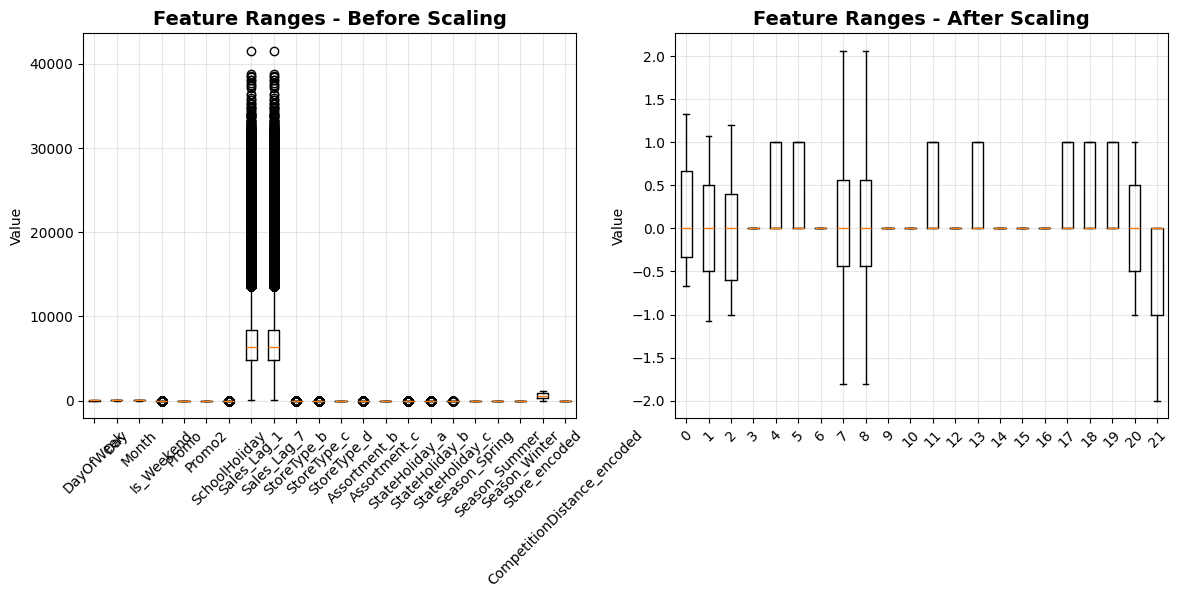

In [161]:
# Visualization: Before vs After
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before scaling
axes[0].boxplot(X.values, labels=X.columns)
axes[0].set_title('Feature Ranges - Before Scaling', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Value')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(Xp.values, labels=Xp.columns)
axes[1].set_title('Feature Ranges - After Scaling', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Value')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)


In [85]:
X.head()

,DayOfWeek,Day,Month,Is_Weekend,Promo,Promo2,SchoolHoliday,Sales_Lag_1,Sales_Lag_7,StoreType_b,...,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,StateHoliday_c,Season_Spring,Season_Summer,Season_Winter,Store_encoded,CompetitionDistance_encoded
1012750,5,4,1,0,0,0,1,5173.0,5509.0,0,...,0,0,0,0,0,0,0,1,1,1
230805,1,5,1,0,1,0,1,4486.0,4969.0,0,...,0,0,0,0,0,0,0,1,1,1
1011635,6,5,1,1,0,0,1,6239.0,5530.0,0,...,0,0,0,0,0,0,0,1,1,1
229690,2,6,1,0,1,0,1,4997.0,5023.0,0,...,0,0,0,0,0,0,0,1,1,1
603545,1,6,1,0,1,0,1,4574.0,4190.0,0,...,0,0,0,0,0,0,0,1,1,1


In [168]:
# Improved data splitting with validation set
X_temp, X_test, y_temp, y_test = train_test_split(
    Xp, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=config.VAL_SIZE, random_state=config.RANDOM_STATE
)

X_temp2, X_test2, y_temp2, y_test2 = train_test_split(
    X, y, test_size=config.TEST_SIZE, random_state=config.RANDOM_STATE
)

X_train2, X_val2, y_train2, y_val2 = train_test_split(
    X_temp2, y_temp2, test_size=config.VAL_SIZE, random_state=config.RANDOM_STATE
)

print(f"📊 DATA SPLITS (IMPROVED from previous notebook):")
print(f"• Training: {X_train.shape[0]:,} samples (model learning)")
print(f"• Validation: {X_val.shape[0]:,} samples (hyperparameter tuning)") 
print(f"• Test: {X_test.shape[0]:,} samples (final evaluation - NEVER TOUCHED until end)")


📊 DATA SPLITS (IMPROVED from previous notebook):
• Training: 535,380 samples (model learning)
• Validation: 133,846 samples (hyperparameter tuning)
• Test: 167,307 samples (final evaluation - NEVER TOUCHED until end)


In [ ]:
print("🚀 STARTING ADVANCED MODEL EVALUATION...")
results = {}
trained_models = {}

for name, model in advanced_models.items():
    print(f"\n🔧 Training {name}...")
    if(name=='Gradient Boosting'):
        metrics, trained_model = evaluate_model_advanced(model, X_train2, X_val2, y_train2, y_val2, name)

    else:
        metrics, trained_model = evaluate_model_advanced(model, X_train, X_val, y_train, y_val, name)
    
    results[name] = metrics
    trained_models[name] = trained_model

    overfit_flag = "⚠️" if metrics['overfitting_gap'] > 0.1 else "✅"
    print(f"✅ {name:20} | Val R²: {metrics['val_r2']:.4f} | "
          f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} {overfit_flag}")

print("\n📈 All models trained and logged to MLflow!")
print(f"💡 Launch MLflow UI with: mlflow ui --backend-store-uri {config.EXPERIMENT_DIR}")


🚀 STARTING ADVANCED MODEL EVALUATION...

🔧 Training Linear Regression...
✅ Linear Regression    | Val R²: 0.6071 | CV R²: 0.6101 ± 0.0009 ✅

🔧 Training Ridge Regression...
✅ Ridge Regression     | Val R²: 0.6071 | CV R²: 0.6101 ± 0.0009 ✅

🔧 Training Lasso Regression...
✅ Lasso Regression     | Val R²: 0.6071 | CV R²: 0.6101 ± 0.0009 ✅

🔧 Training ElasticNet...
✅ ElasticNet           | Val R²: 0.5131 | CV R²: 0.5151 ± 0.0012 ✅

🔧 Training Random Forest...
✅ Random Forest        | Val R²: 0.7275 | CV R²: 0.7240 ± 0.0009 ✅

🔧 Training Gradient Boosting...
✅ Gradient Boosting    | Val R²: 0.8612 | CV R²: 0.8610 ± 0.0019 ✅

🔧 Training XGB...
✅ XGB                  | Val R²: 0.7527 | CV R²: 0.7559 ± 0.0015 ✅

🔧 Training Voting Ensemble...
✅ Voting Ensemble      | Val R²: 0.7664 | CV R²: 0.7651 ± 0.0007 ✅

📈 All models trained and logged to MLflow!
💡 Launch MLflow UI with: mlflow ui --backend-store-uri experiments


In [169]:
results = {}
trained_models = {}
print(f"\n🔧 Training Gradient Boosting ...")
metrics, trained_model = evaluate_model_advanced(advanced_models['Gradient Boosting'], X_train, X_val, y_train, y_val)
    
results['Gradient Boosting with scaling'] = metrics
trained_models['Gradient Boosting with scaling'] = trained_model

overfit_flag = "⚠️" if metrics['overfitting_gap'] > 0.1 else "✅"
print(f"✅ {name:20} | Val R²: {metrics['val_r2']:.4f} | "
     f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} {overfit_flag}")


🔧 Training Gradient Boosting ...
✅ Voting Ensemble      | Val R²: 0.8612 | CV R²: 0.8610 ± 0.0019 ✅


In [171]:
print (metrics)

{'train_rmse': np.float64(1052.5220100996796), 'val_rmse': np.float64(1155.3240969635006), 'train_r2': 0.8852548950551087, 'val_r2': 0.861225630323983, 'train_mae': 765.5474799103858, 'val_mae': 821.2919412083771, 'training_time': 1256.230571269989, 'overfitting_gap': 0.024029264731125655, 'cv_r2_mean': np.float64(0.8610446117988072), 'cv_r2_std': np.float64(0.0019356303369322146)}


In [172]:
print(f"\n🔧 Training Gradient Boosting ...")
metrics2, trained_model2 = evaluate_model_advanced(advanced_models['Gradient Boosting'], X_train2, X_val2, y_train2, y_val2)
    
results[name] = metrics2
trained_models[name] = trained_model2

overfit_flag = "⚠️" if metrics['overfitting_gap'] > 0.1 else "✅"
print(f"✅ {name:20} | Val R²: {metrics['val_r2']:.4f} | "
     f"CV R²: {metrics['cv_r2_mean']:.4f} ± {metrics['cv_r2_std']:.4f} {overfit_flag}")


🔧 Training Gradient Boosting ...
✅ Voting Ensemble      | Val R²: 0.8612 | CV R²: 0.8610 ± 0.0019 ✅


In [173]:
print(metrics2)

{'train_rmse': np.float64(1037.048618023167), 'val_rmse': np.float64(1142.981431779713), 'train_r2': 0.888603889134221, 'val_r2': 0.8641749259724717, 'train_mae': 758.0836991794746, 'val_mae': 815.0516250520355, 'training_time': 1157.3881735801697, 'overfitting_gap': 0.02442896316174925, 'cv_r2_mean': np.float64(0.865746465803309), 'cv_r2_std': np.float64(0.001862432725902338)}


📊 Model comparison table:


,Model,val_r2,val_rmse,val_mae,overfitting_gap,cv_r2_mean
0,Linear Regression,0.607095,1943.985033,1398.470161,0.003022,0.610098
1,Ridge Regression,0.607095,1943.985013,1398.469709,0.003022,0.610098
2,Lasso Regression,0.607095,1943.984375,1398.449420,0.003022,0.610098
3,ElasticNet,0.513130,2163.993058,1541.761143,0.001962,0.515084
4,Random Forest,0.727465,1619.050467,1158.078963,0.006497,0.723959
5,Gradient Boosting,0.861226,1155.324097,821.291941,0.024029,0.861045
6,XGB,0.752746,1542.129129,1106.591309,0.005078,0.755890
7,Voting Ensemble,0.766415,1498.897748,1072.983572,0.063763,0.765059


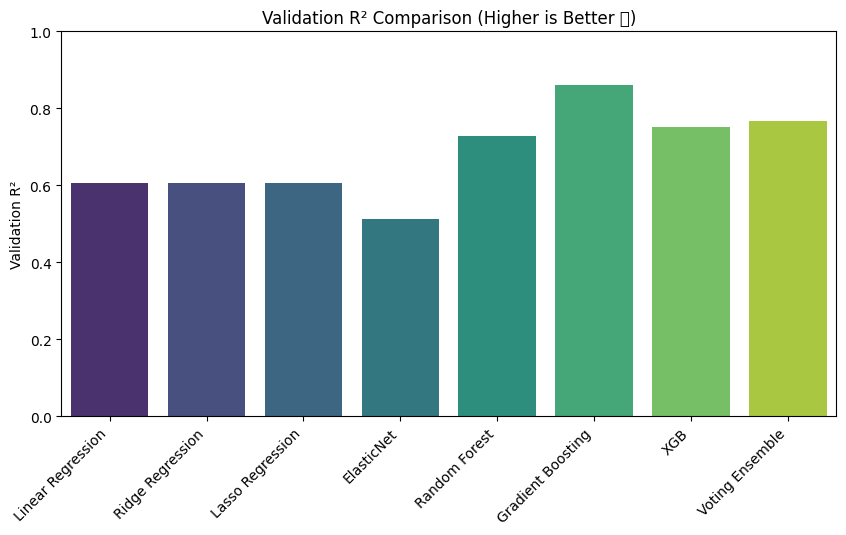

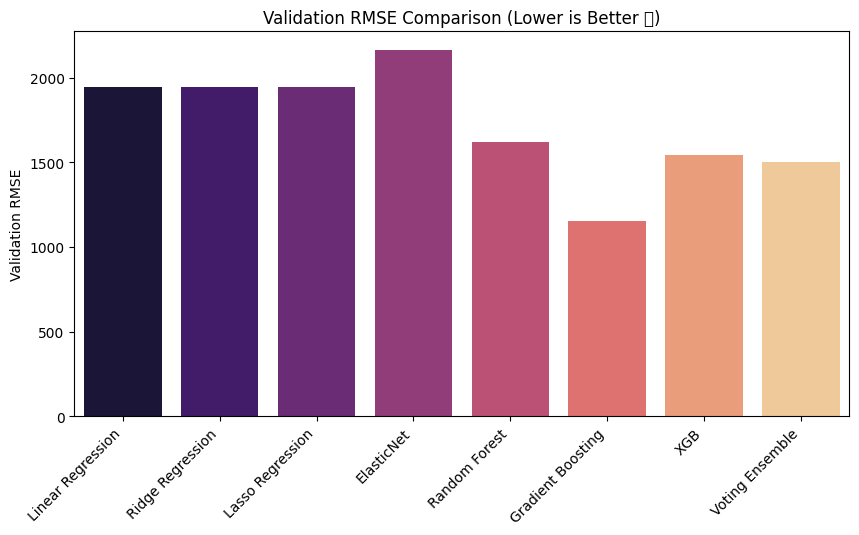

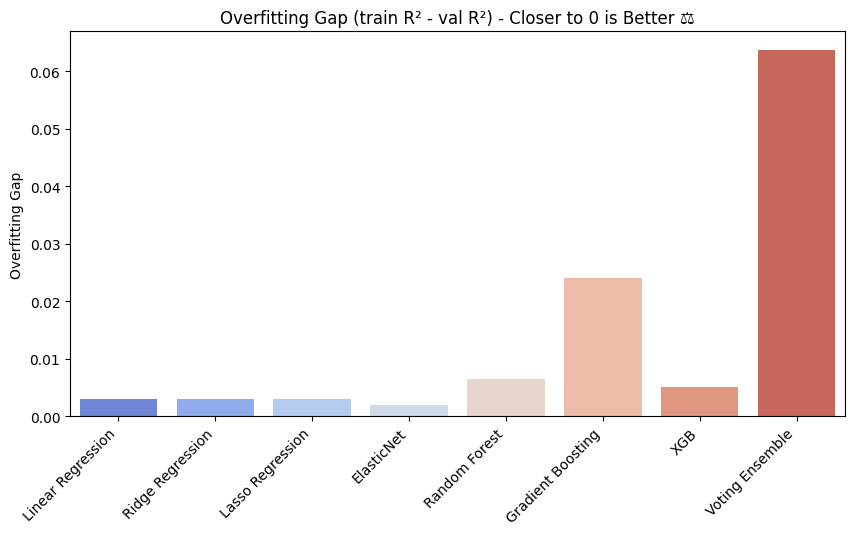

In [117]:


# ===========================
# 1️⃣ Convert results dict to DataFrame
# ===========================
metrics_df = pd.DataFrame(results).T  # transpose so models are rows
metrics_df = metrics_df[['val_r2', 'val_rmse', 'val_mae', 'overfitting_gap', 'cv_r2_mean']]
metrics_df = metrics_df.reset_index().rename(columns={'index': 'Model'})

print("📊 Model comparison table:")
display(metrics_df)

# ===========================
# 2️⃣ Plot Validation R² (Higher is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_r2', palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Validation R² Comparison (Higher is Better ✅)')
plt.ylabel('Validation R²')
plt.xlabel('')
plt.ylim(0, 1)
plt.show()

# ===========================
# 3️⃣ Plot Validation RMSE (Lower is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='val_rmse', palette='magma')
plt.xticks(rotation=45, ha='right')
plt.title('Validation RMSE Comparison (Lower is Better ✅)')
plt.ylabel('Validation RMSE')
plt.xlabel('')
plt.show()

# ===========================
# 4️⃣ Plot Overfitting Gap (Closer to 0 is better)
# ===========================
plt.figure(figsize=(10, 5))
sns.barplot(data=metrics_df, x='Model', y='overfitting_gap', palette='coolwarm')
plt.xticks(rotation=45, ha='right')
plt.title('Overfitting Gap (train R² - val R²) - Closer to 0 is Better ⚖️')
plt.ylabel('Overfitting Gap')
plt.xlabel('')
plt.show()


In [125]:
Model_W=trained_models['Gradient Boosting']

In [160]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import numpy as np


# Predict on test set
y_test_pred = Model_W.predict(X_test)

# Compute performance metrics
test_r2 = r2_score(y_test, y_test_pred)
test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
Test_mse=mean_squared_error(y_test, y_test_pred)

print(f"📊 Test R²: {test_r2:.4f}")
print(f"📊 Test RMSE: {test_rmse:.4f}")
print(f"📊 Test MAE: {test_mae:.4f}")
print(f"📊 Test MSE: {Test_mse:.4f}")



📊 Test R²: 0.8652
📊 Test RMSE: 1143.1138
📊 Test MAE: 818.4186
📊 Test MSE: 1306709.0623


In [177]:
# ===========================
# 3️⃣ Versioning and saving
# ===========================
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_version = f"v1_{timestamp}"
model_save_dir = os.path.join(config.MODEL_DIR, model_version)
os.makedirs(model_save_dir, exist_ok=True)

# Save model
model_path = os.path.join(model_save_dir, 'best_model.pkl')
joblib.dump(Model_W, model_path)
print(f"✅ Model saved: {model_path}")

# Save preprocessing pipeline
preprocessor_path = os.path.join(model_save_dir, 'preprocessor.pkl')
joblib.dump(preprocessor, preprocessor_path)
print(f"✅ Preprocessor saved: {preprocessor_path}")
# ===========================
# 5️⃣ Deployment requirements
# ===========================
requirements = {
    'python': '3.8+',
    'packages': {
        'scikit-learn': '1.0+',
        'numpy': '1.20+',
        'pandas': '1.3+',
        'joblib': '1.0+',
    }
}

req_path = os.path.join(model_save_dir, 'requirements.json')
with open(req_path, 'w') as f:
    json.dump(requirements, f, indent=2)
print(f"✅ Deployment requirements saved: {req_path}")

✅ Model saved: models\v1_20260303_202614\best_model.pkl
✅ Preprocessor saved: models\v1_20260303_202614\preprocessor.pkl
✅ Deployment requirements saved: models\v1_20260303_202614\requirements.json


In [1]:
X.info()

NameError: name 'X' is not defined

In [21]:
import gradio as gr
import joblib

List=['DayOfWeek','Day','Month','Is_Weekend','Promo','Promo2','SchoolHoliday','Sales_Lag_1','Sales_Lag_7','StoreType_b',
      'StoreType_c','StoreType_d','Assortment_b','Assortment_c','StateHoliday_a','StateHoliday_b','StateHoliday_c','Season_Spring'
      ,'Season_Summer','Season_Winter','Store_encoded','CompetitionDistance_encoded']
# -------------------------------
# Load the trained Random Forest pipeline model
# -------------------------------
Model_test = joblib.load("models\\v1_20260303_202614\\best_model.pkl")  # make sure this file exists in the same directory

# -------------------------------
# Function to predict nasa  jet engine
# -------------------------------
def Sales_Pred(DayOfWeek,Day,Month, Is_Weekend, Promo, Promo2, SchoolHoliday, Sales_Lag_1, Sales_Lag_7,
               StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,
               StateHoliday_c,Season_Spring,Season_Summer,Season_Winter,Store_encoded,CompetitionDistance_encoded):
    # Arrange features in the exact order used during training
    X = [[DayOfWeek,Day, Month, Is_Weekend, Promo, Promo2, SchoolHoliday, Sales_Lag_1, Sales_Lag_7,StoreType_b,StoreType_c,
          StoreType_d,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,StateHoliday_c
          ,Season_Spring,Season_Summer,Season_Winter,Store_encoded,CompetitionDistance_encoded]]
    predicted_RUL = Model_test.predict(X)[0]  # Convert to $k
    return f"{predicted_RUL:.2f}"

# -------------------------------
# Predefined sample jet engine (examples)
# -------------------------------
examples = [
    # Example 1: Engine Early Life (Unit 1, Cycle 50) - Expect High RUL
    [-0.0018, 0.0003, 100.0, 643.31, 1604.99, 1424.37, 551.87, 2388.23, 9071.18, 48.06, 520.09, 2388.23, 8150.31, 8.5220, 396.11, 38.45, 23.0121,2,3,4,5,6,7,89,12,34,56,78,907 ,2,32,44,54,23,11,22,33,44,555,5,2,354,65, 0],
    # Example 2: Engine Mid Life (Unit 2, Cycle 150) - Expect Moderate RUL
    [-0.0017, -0.0004, 100.0, 642.87, 1599.04, 1419.01, 552.48, 2388.13, 9062.88, 47.88, 520.84, 2388.12, 8146.46, 8.4897, 393.64, 38.69, 23.1695,32.45,45,65,78,454,345,345 ,345,345,4523,5,4668,8,65765,3,4,6,7,89,76,45,34,45,5,6,6, 0],
    # Example 3: Engine Late Life (Unit 3, Cycle 180) - Expect Low RUL
    [-0.0018, 0.0003, 100.0, 643.31, 1604.99, 1424.37, 551.87, 2388.23, 9071.18, 48.06, 520.09, 2388.23, 8150.31, 8.5220, 396.11, 38.45, 23.0121,2,3,4,5,6,7,89,12,34,56,78,907 ,2,32,44,54,23,11,22,33,44,555,5,2,354,65, 0] 
]

# -------------------------------
# Gradio interface
# -------------------------------
iface = gr.Interface(
    fn=Sales_Pred,
  inputs = [
      
          gr.Number(value=642.0, label=item)
          for item in List

  
    # --- Constant Sensor Measurements ---
    # These are needed for the preprocessor but shouldn't be changed by the user.
],
    outputs=gr.Textbox(label="Predicted RUL "),
    title="Sales Prediction",
    description="Adjust the sliders to predict the Sales.",
    examples=examples
)

# -------------------------------
# Launch the Gradio app
# -------------------------------
iface.launch(share=True)


* Running on local URL:  http://127.0.0.1:7861

Could not create share link. Missing file: C:\Users\DELL\.cache\huggingface\gradio\frpc\frpc_windows_amd64_v0.3. 

Please check your internet connection. This can happen if your antivirus software blocks the download of this file. You can install manually by following these steps: 

1. Download this file: https://cdn-media.huggingface.co/frpc-gradio-0.3/frpc_windows_amd64.exe
2. Rename the downloaded file to: frpc_windows_amd64_v0.3
3. Move the file to this location: C:\Users\DELL\.cache\huggingface\gradio\frpc
